# Входные документы пилота

Анализ входных пакетов документов: 
- сколько позиций и PDF по классам
- как реестр связывает позицию с файлами
- чем отличаются наборы из контура укидим и нси


## Подготовка


In [1]:
from __future__ import annotations

import os
from collections import Counter
from pathlib import Path

import matplotlib.pyplot as plt
import pandas as pd
from pypdf import PdfReader

pd.set_option("display.max_columns", 20)
pd.set_option("display.width", 120)
plt.rcParams.update(
    {
        "figure.figsize": (7, 3.5),
        "axes.grid": True,
        "axes.axisbelow": True,
        "font.size": 11,
        "font.family": "DejaVu Sans",
    }
)


def resolve_data_root() -> Path:
    """Каталог data.local с пилотными пакетами. Можно задать NSI_DATA_ROOT."""
    env = os.environ.get("NSI_DATA_ROOT")
    candidates: list[Path] = []
    if env:
        candidates.append(Path(env).expanduser())
    candidates.append(Path.home() / "projects/nsi-attribute-extraction/data.local")
    cwd = Path.cwd()
    candidates.extend(
        [
            cwd / "data.local",
            cwd.parent / "nsi-attribute-extraction" / "data.local",
        ]
    )
    for c in candidates:
        if (c / "input_data_ukidim").is_dir() and (c / "input_data_handmade").is_dir():
            return c.resolve()
    raise FileNotFoundError(
        "Не найден data.local с input_data_ukidim и input_data_handmade. "
        "Укажите NSI_DATA_ROOT."
    )


DATA = resolve_data_root()
UKI = DATA / "input_data_ukidim"
RAW = DATA / "input_data_raw"
HAND = DATA / "input_data_handmade"
PDF_DIR = UKI / "pdf"

CLASS_LABEL = {
    "bak": "Баки",
    "heat_exchanger": "Теплообменники",
    "strainer": "Фильтры сетчатые",
}

print("DATA =", DATA)
print("PDF в ukidim/pdf:", len(list(PDF_DIR.iterdir())) if PDF_DIR.is_dir() else 0)


DATA = /home/fyodebadylo/projects/nsi-attribute-extraction/data.local
PDF в ukidim/pdf: 55


## Сколько позиций и документов по классам

Три класса оборудования. Считаем по рабочему handmade-манифесту ukidim — не по всему, что лежит в `pdf/`.


In [2]:
manifest = pd.read_excel(HAND / "ukidim_pdf_files_manifest.xlsx")
manifest.columns = [
    "eos_id",
    "filename",
    "processing_order",
    "variant_id",
    "class_code",
    "recpart",
]
manifest["class_label"] = manifest["class_code"].map(CLASS_LABEL)

rows = []
for code, g in manifest.groupby("class_code"):
    rows.append(
        {
            "класс": CLASS_LABEL[code],
            "позиции": g["eos_id"].nunique(),
            "PDF в манифесте": len(g),
            "позиции с вариантом исполнения": int(g.loc[g["variant_id"].notna(), "eos_id"].nunique()),
            "позиции с несколькими PDF": int((g.groupby("eos_id").size() > 1).sum()),
            "атрибутов в справочнике": len(pd.read_excel(UKI / "meta" / code / "attributes_set.xlsx")),
        }
    )
pack = pd.DataFrame(rows).sort_values("класс").reset_index(drop=True)
pack


,класс,позиции,PDF в манифесте,позиции с вариантом исполнения,позиции с несколькими PDF,атрибутов в справочнике
0,Баки,10,16,6,4,170
1,Теплообменники,8,10,1,2,183
2,Фильтры сетчатые,10,12,3,2,147


eda_docs.ipynb:5:10: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown


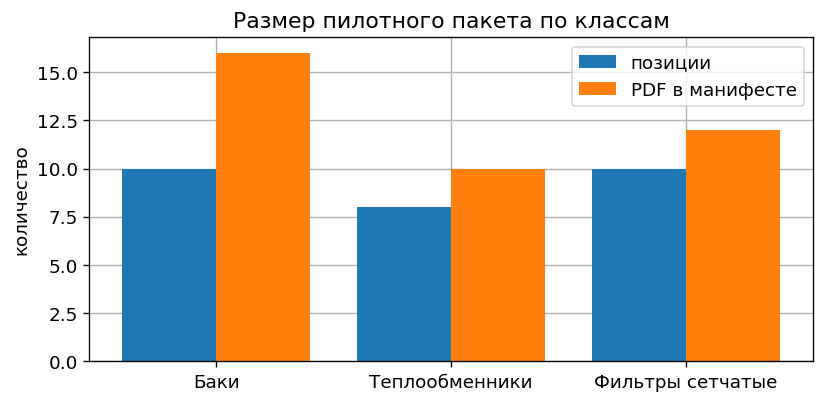

In [3]:
fig, ax = plt.subplots()
x = range(len(pack))
ax.bar([i - 0.2 for i in x], pack["позиции"], width=0.4, label="позиции")
ax.bar([i + 0.2 for i in x], pack["PDF в манифесте"], width=0.4, label="PDF в манифесте")
ax.set_xticks(list(x), pack["класс"])
ax.set_ylabel("количество")
ax.set_title("Размер пилотного пакета по классам")
ax.legend()
plt.tight_layout()
plt.show()


**Вывод.** Классы очень разные по объёму: где-то почти «одна позиция — один PDF», где-то комплекты и варианты исполнения, плюс разная длина справочника атрибутов. Дальше любые сравнения между классами «лоб в лоб» будут вводить в заблуждение.


## Чем реестр склеивает позицию с файлами

В манифесте не только имя файла: порядок обработки (основной / дополнения), вариант исполнения, класс, связка с эталонной выгрузкой.


In [4]:
field_roles = pd.DataFrame(
    [
        ("eos_id", "ключ проектной позиции"),
        ("filename", "конкретный PDF в комплекте"),
        ("processing_order", "0 — основной документ, больше — более позднее дополнение"),
        ("variant_id", "вариант исполнения, если в одном ТЗ несколько"),
        ("class_code", "класс → какой справочник атрибутов брать"),
        ("recpart", "связка с эталонной выгрузкой значений"),
    ],
    columns=["поле", "зачем"],
)
field_roles


,поле,зачем
0,eos_id,ключ проектной позиции
1,filename,конкретный PDF в комплекте
2,processing_order,"0 — основной документ, больше — более позднее дополнение"
3,variant_id,"вариант исполнения, если в одном ТЗ несколько"
4,class_code,класс → какой справочник атрибутов брать
5,recpart,связка с эталонной выгрузкой значений


In [5]:
docs_per_pos = manifest.groupby("eos_id").size()
stats = pd.Series(
    {
        "позиций всего": int(manifest["eos_id"].nunique()),
        "с одним PDF": int((docs_per_pos == 1).sum()),
        "с дополнениями (order > 0)": int((manifest.groupby("eos_id")["processing_order"].max() > 0).sum()),
        "позиций с variant_id": int(manifest.loc[manifest["variant_id"].notna(), "eos_id"].nunique()),
        "RECPart заполнен везде": bool(manifest["recpart"].notna().all()),
    },
    name="значение",
).to_frame()
stats


,значение
позиций всего,28
с одним PDF,20
с дополнениями (order > 0),8
позиций с variant_id,10
RECPart заполнен везде,True


**Вывод.** Целевое значение живёт не «в файле», а у позиции (иногда ещё и у варианта исполнения), а документный источник — весь комплект. Имеет смысл дальше оперировать позицией + набором PDF, а не отдельными файлами. RECPart нужен, чтобы потом сопоставить эталон.


## Манифест vs то, что лежит на диске

Проверяем, совпадает ли рабочий список файлов с содержимым `pdf/`.


In [6]:
on_disk = {p.name for p in PDF_DIR.iterdir() if p.is_file()}
in_manifest = set(manifest["filename"])
disk_vs_manifest = pd.Series(
    {
        "файлов на диске": len(on_disk),
        "имён в манифесте": len(in_manifest),
        "на диске, но не в манифесте": len(on_disk - in_manifest),
        "в манифесте, но нет на диске": len(in_manifest - on_disk),
    },
    name="количество",
).to_frame()
disk_vs_manifest


,количество
файлов на диске,55
имён в манифесте,38
"на диске, но не в манифесте",17
"в манифесте, но нет на диске",0


In [7]:
raw_manifest = pd.read_excel(HAND / "pdf_files_manifest.xlsx")
raw_manifest.columns = ["eos_id", "filename", "processing_order", "variant_id"]
raw_files = [p for p in RAW.iterdir() if p.is_file()] if RAW.is_dir() else []
raw_overview = pd.Series(
    {
        "строк в raw-манифесте": len(raw_manifest),
        "уникальных позиций": int(raw_manifest["eos_id"].nunique()),
        "файлов в raw-папке": len(raw_files),
        "расширения": dict(Counter(p.suffix.lower() for p in raw_files)),
    },
    name="raw (контраст)",
).to_frame()
raw_overview


,raw (контраст)
строк в raw-манифесте,46
уникальных позиций,41
файлов в raw-папке,48
расширения,"{'.pdf': 47, '.png': 1}"


**Вывод.** На диске есть лишние файлы относительно манифеста. Если индексировать папку целиком, в выборку попадут сироты. Для экспериментов надёжнее держаться манифеста: иначе неясно, что основное, что дополнение и что вообще в scope.


## Какие это вообще документы

Грубая разметка по имени файла (ТЗ / ТУ / дополнение / прочее) — чтобы сравнить курируемый набор и сырую папку.


In [8]:
def doc_kind(name: str) -> str:
    n = name.lower()
    if "дополнен" in n:
        return "дополнение"
    if "тз" in n:
        return "ТЗ"
    if "ту" in n:
        return "ТУ"
    if "паспорт" in n:
        return "паспорт"
    if "спецификац" in n:
        return "спецификация"
    if "гост" in n:
        return "ГОСТ"
    if "каталог" in n or "katalog" in n:
        return "каталог"
    if "сертифик" in n:
        return "сертификат"
    if Path(name).suffix.lower() in {".png", ".jpg", ".jpeg", ".tif", ".tiff"}:
        return "изображение"
    return "прочее"


uki_kinds = manifest["filename"].map(doc_kind).value_counts().rename("ukidim")
raw_kinds = (
    pd.Series([doc_kind(p.name) for p in raw_files]).value_counts().rename("raw")
    if raw_files
    else pd.Series(dtype=int, name="raw")
)
kinds = pd.concat([uki_kinds, raw_kinds], axis=1).fillna(0).astype(int)
kinds


,ukidim,raw
ТЗ,28,6
дополнение,10,0
ТУ,0,19
прочее,0,17
спецификация,0,2
каталог,0,1
паспорт,0,1
ГОСТ,0,1
изображение,0,1


eda_docs.ipynb:17:10: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown


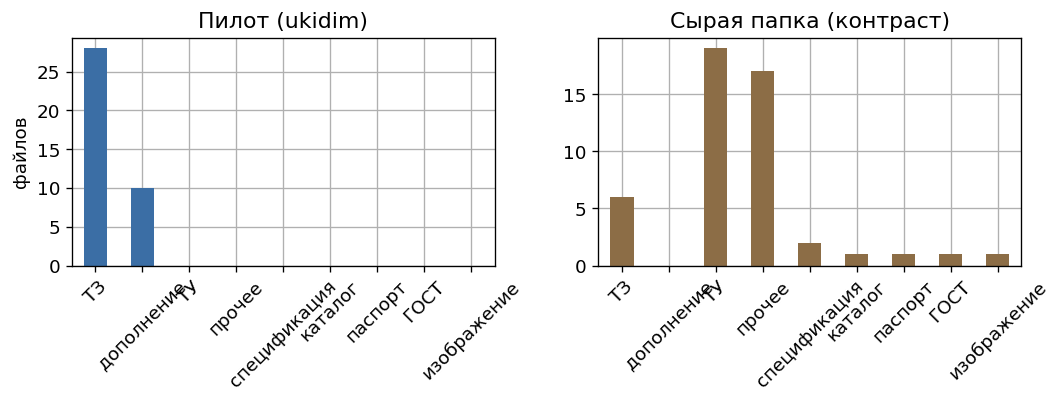

In [9]:
fig, axes = plt.subplots(1, 2, figsize=(9, 3.5))
kinds["ukidim"].plot(kind="bar", ax=axes[0], color="#3b6ea5")
axes[0].set_title("Пилот (ukidim)")
axes[0].set_ylabel("файлов")
kinds["raw"].plot(kind="bar", ax=axes[1], color="#8c6d46")
axes[1].set_title("Сырая папка (контраст)")
for ax in axes:
    ax.tick_params(axis="x", rotation=45)
plt.tight_layout()
plt.show()


**Вывод.** В ukidim почти сплошь ТЗ и дополнения. В raw рядом ТУ, каталоги, сертификаты, картинки. То есть «всё, что прислали» — это не однородная техдокументация; без отбора вход будет шумным.


## Есть ли текстовый слой

По нескольким страницам PDF считаем средний объём извлекаемого текста. Мало символов на страницу — похоже на скан или пустой текстовый слой.


In [10]:
def sample_chars_per_page(path: Path, head: int = 3) -> tuple[int | None, float | None]:
    try:
        reader = PdfReader(str(path))
        n = len(reader.pages)
        idxs = list(range(min(head, n)))
        if n > head:
            idxs.append(n - 1)
        chars = 0
        for i in idxs:
            chars += len((reader.pages[i].extract_text() or "").strip())
        return n, chars / max(len(idxs), 1)
    except Exception:
        return None, None


def text_layer_frame(files: list[Path]) -> pd.DataFrame:
    rows = []
    for p in files:
        if p.suffix.lower() != ".pdf":
            continue
        pages, cpp = sample_chars_per_page(p)
        if pages is None:
            continue
        rows.append(
            {
                "страниц": pages,
                "символов_на_страницу": cpp,
                "размер_МБ": p.stat().st_size / 1e6,
            }
        )
    return pd.DataFrame(rows)


uki_pdfs = [PDF_DIR / fn for fn in manifest["filename"] if (PDF_DIR / fn).exists()]
uki_tl = text_layer_frame(uki_pdfs)
raw_pdfs = [p for p in raw_files if p.suffix.lower() == ".pdf"]
raw_tl = text_layer_frame(raw_pdfs)


def summarize(df: pd.DataFrame, name: str) -> dict:
    return {
        "пакет": name,
        "PDF": len(df),
        "страниц (медиана)": float(df["страниц"].median()) if len(df) else None,
        "симв./стр. (медиана)": float(df["символов_на_страницу"].median()) if len(df) else None,
        "похоже на скан (<20)": int((df["символов_на_страницу"] < 20).sum()) if len(df) else 0,
        "слабый текст (<100)": int((df["символов_на_страницу"] < 100).sum()) if len(df) else 0,
    }


text_summary = pd.DataFrame([summarize(uki_tl, "ukidim"), summarize(raw_tl, "raw")])
text_summary


,пакет,PDF,страниц (медиана),симв./стр. (медиана),похоже на скан (<20),слабый текст (<100)
0,ukidim,38,37.5,1099.5,6,6
1,raw,47,30.0,280.0,19,19


eda_docs.ipynb:21:10: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown


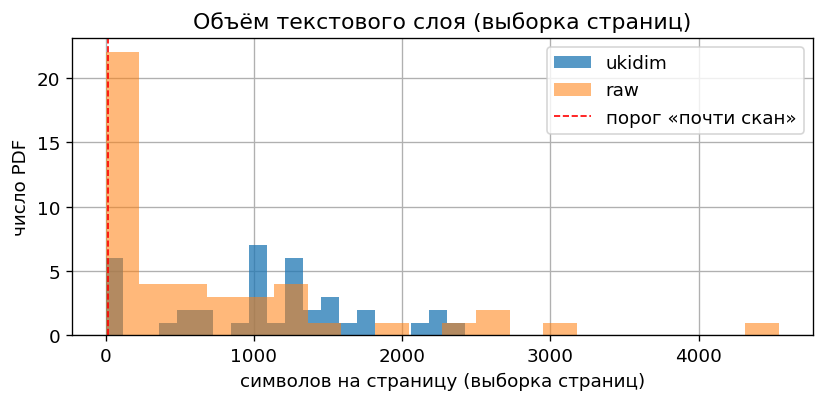

In [11]:
fig, ax = plt.subplots()
ax.hist(uki_tl["символов_на_страницу"], bins=20, alpha=0.75, label="ukidim")
ax.hist(raw_tl["символов_на_страницу"], bins=20, alpha=0.55, label="raw")
ax.axvline(20, color="red", linestyle="--", linewidth=1, label="порог «почти скан»")
ax.set_xlabel("символов на страницу (выборка страниц)")
ax.set_ylabel("число PDF")
ax.set_title("Объём текстового слоя (выборка страниц)")
ax.legend()
plt.tight_layout()
plt.show()


**Вывод.** Даже в курируемом наборе есть почти «немые» PDF; в raw таких заметно больше. Пока разумно ограничиться документами с текстовым слоем. Сканы — отдельная ветка работы.


## Где обычно живут значения

На текстовых PDF смотрим начало документа: маркеры таблиц и насколько страницы насыщены числами. Это не полный разбор вёрстки, а быстрая проверка гипотезы, что характеристики редко лежат ровным абзацем.


In [12]:
def structure_flags(path: Path, max_pages: int = 5) -> dict:
    reader = PdfReader(str(path))
    text = "\n".join(
        (reader.pages[i].extract_text() or "") for i in range(min(max_pages, len(reader.pages)))
    )
    if len(text.strip()) < 200:
        return {"есть_текст": False, "маркер_таблицы": False, "много_чисел": False}
    low = text.lower()
    lines = [ln.strip() for ln in text.splitlines() if ln.strip()]
    numish = sum(1 for ln in lines if any(ch.isdigit() for ch in ln))
    return {
        "есть_текст": True,
        "маркер_таблицы": ("таблица" in low) or ("табл." in low) or (text.count("\t") > 20),
        "много_чисел": (numish / max(len(lines), 1)) > 0.35,
    }


rich_paths = [
    p
    for p, cpp in zip(uki_pdfs, uki_tl["символов_на_страницу"])
    if cpp >= 100
][:20]
flags = pd.DataFrame([structure_flags(p) for p in rich_paths])
structure_summary = pd.Series(
    {
        "проверено текстовых PDF": len(flags),
        "с маркерами таблицы": int(flags["маркер_таблицы"].sum()),
        "с числоёмкими страницами": int(flags["много_чисел"].sum()),
    },
    name="количество",
).to_frame()
structure_summary


,количество
проверено текстовых PDF,20
с маркерами таблицы,9
с числоёмкими страницами,17


**Вывод.** Полезные куски часто табличные / «числоёмкие», плюс шум титулов и штампов. Нарезка документа в плоский plain text без учёта структуры, скорее всего, потеряет часть сигналов.


## Коротко по документам

Неоднородность классов; единица учёта — позиция с комплектом PDF; папка ≠ датасет; вход надо фильтровать по типу документа и наличию текста; структура (таблицы/разделы) важна. Дальше — справочники атрибутов и эталон.
